# Lab 4, Day 2 — Fashion-MNIST Classification

Build a classifier with proper validation tracking and early stopping, then read a
confusion matrix as an error-analysis tool rather than decoration. See
`Lab4_Day2_Instructions.md` for the full walkthrough.

This notebook is just a shell: the data loading, model, training loop, and analysis
are yours to write.

In [14]:
import random

import matplotlib.pyplot as plt
import torch
from torch import nn, optim

from stage_b_classification import (
    load_fashion_mnist,
    plot_class_averages,
    plot_class_examples,
    plot_confusion_matrix,
)
from train import build_mlp, find_lr, training

random.seed(42)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)


mps


## Step 1: Load Fashion-MNIST and prepare loaders (`stage_b_classification.py`)

In [15]:
# shuffle only on train — shuffling val/test doesn't change the metrics, just wastes time
train_loader, val_loader, test_loader, class_names = load_fashion_mnist(
    data_root="./data",
    train_ratio=0.8,
    batch_size=64,
    seed=42,
)

print(len(train_loader.dataset), "train |",
      len(val_loader.dataset), "val |",
      len(test_loader.dataset), "test")
print(class_names)


48000 train | 12000 val | 10000 test
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## Look at the data before you model it

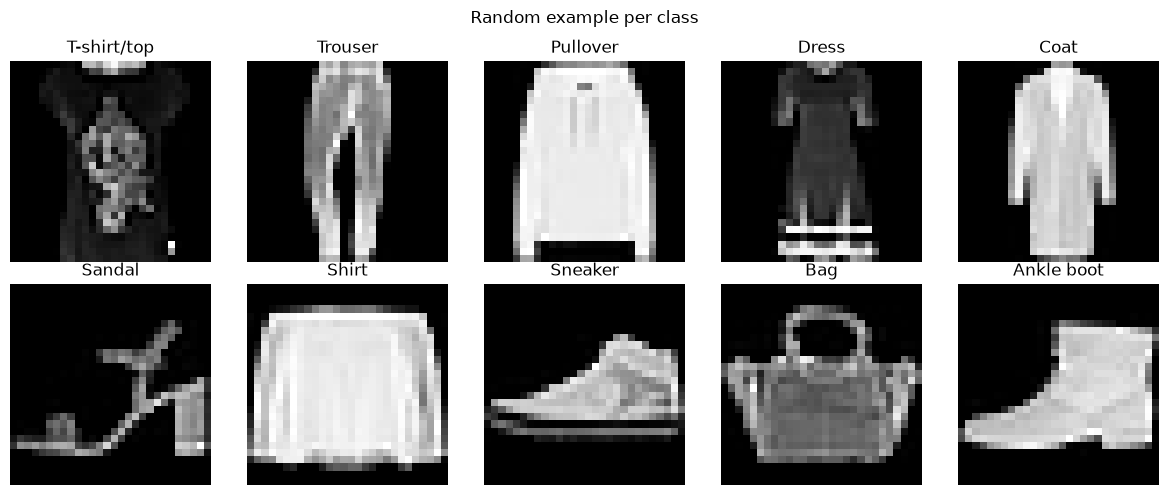

In [16]:
# TODO: plot a handful of example images, one (or a few) per class - use
# train_set.classes for the human-readable label names. This is worth doing before
# you build anything: you will be asked later whether the confusion matrix's mistakes
# are reasonable, and you cannot judge that without having actually looked at the images.


plot_class_examples(train_loader, class_names)



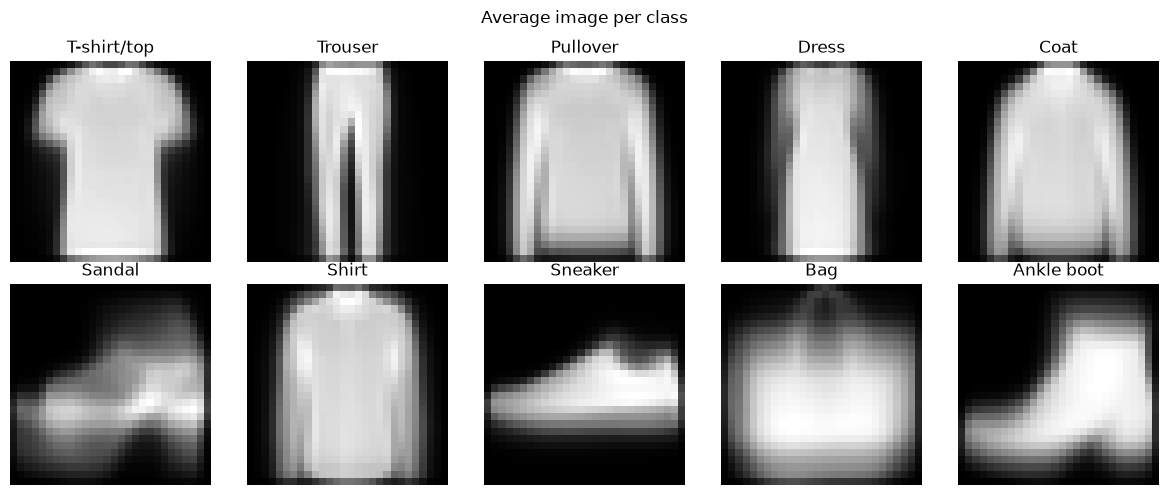

In [17]:
plot_class_averages(train_loader, class_names)


## Step 2: The classifier

In [18]:
# TODO: Flatten -> Linear -> ReLU -> Linear (10 classes), raw scores, NO softmax -
# CrossEntropyLoss applies it internally

# same build_mlp from Day 1 — just a different layer layout
model = build_mlp([784, 256, 128, 10], act="relu").to(device)

# kaiming init helps ReLU networks start in a reasonable range
for m in model.modules():
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
        if m.bias is not None:
            nn.init.zeros_(m.bias)

print(model)

# sanity check shapes before training
x_batch, y_batch = next(iter(train_loader))
print("X:", x_batch.shape, " y:", y_batch.shape, y_batch.dtype)
print("logits:", model(x_batch.to(device)).shape)





MLP(
  (fc_first): Linear(in_features=784, out_features=256, bias=True)
  (hidden): ModuleList(
    (0): Linear(in_features=256, out_features=128, bias=True)
  )
  (fc_last): Linear(in_features=128, out_features=10, bias=True)
  (activation): ReLU()
)
X: torch.Size([64, 784])  y: torch.Size([64]) torch.int64
logits: torch.Size([64, 10])


## Step 3: Train with validation tracking and early stopping

suggested lr: 3.35e-04
using the suggested learning rate


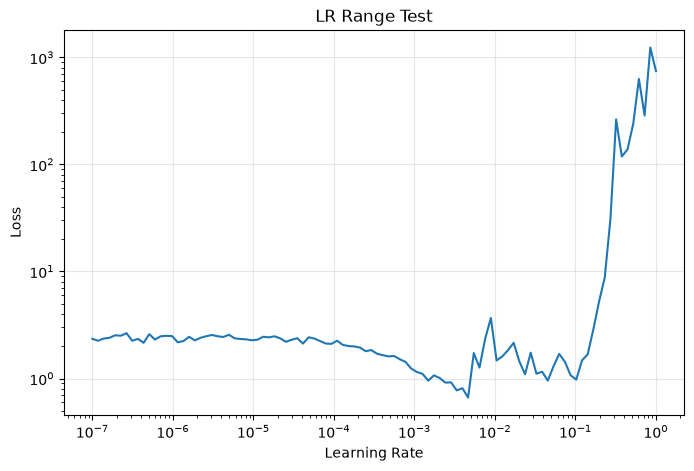

In [19]:
EPOCHS = 50
PATIENCE = 5

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)



suggested_lr, lrs, losses = find_lr(
    model,
    train_loader,
    optimizer,
    loss_fn,
    init_lr=1e-7,
    final_lr=1,
    num_iter=100,
    device=device,
)

print(f"suggested lr: {suggested_lr:.2e}")

optimizer.param_groups[0]["lr"] = suggested_lr
print("using the suggested learning rate")


# optional: look at the curve yourself
plt.figure(figsize=(8, 5))
plt.plot(lrs, losses)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("LR Range Test")
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
model, history = training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
    metrics=["loss", "acc"],
    patience=PATIENCE,
    early_stop_metric="val_acc",
    early_stop_mode="max",
)

print(f"stopped after {len(history['train_loss'])} epochs")


Training:  36%|███▌      | 18/50 [00:40<01:11,  2.22s/it, epoch=19, train_acc=0.939, train_loss=0.1691, val_acc=0.893, val_loss=0.3236]

Early stopping at epoch 19 (no improvement for 5 epochs). Best val_acc=0.8938
stopped after 19 epochs


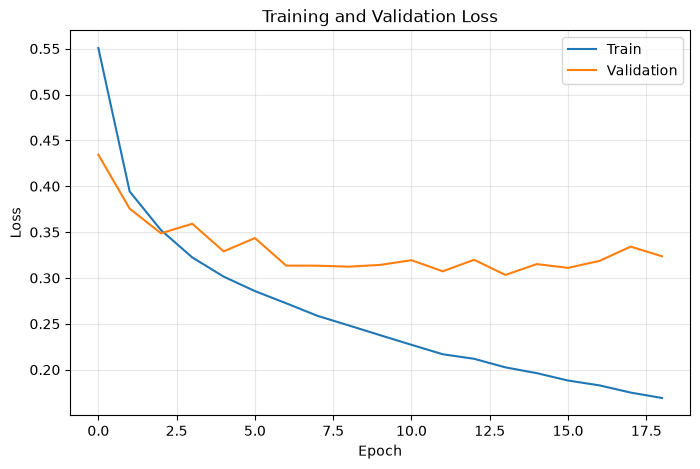

In [21]:
# training loss
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


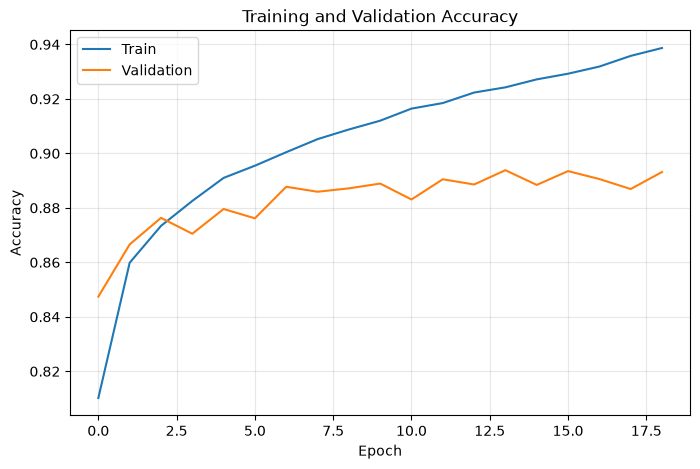

In [22]:
# validation accuracy (this is what early stopping actually watched)
plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



In [23]:
# test accuracy on the held-out set (only now, not during training)
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

print(f"test accuracy: {correct / total:.4f}  ({correct}/{total})")


test accuracy: 0.8866  (8866/10000)


In [24]:
# TODO: train_with_early_stopping (or write it yourself) - track train loss and val
# accuracy per epoch, patience-based stopping (not a single bad epoch), .clone() the
# best state_dict before restoring it



# Early stopping (patience + cloned best state) is handled inside training().
# test accuracy on the held-out set (only now, not during training)

model.eval()
correct, total = 0, 0
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

print(f"test accuracy: {correct / total:.4f}  ({correct}/{total})")


test accuracy: 0.8866  (8866/10000)


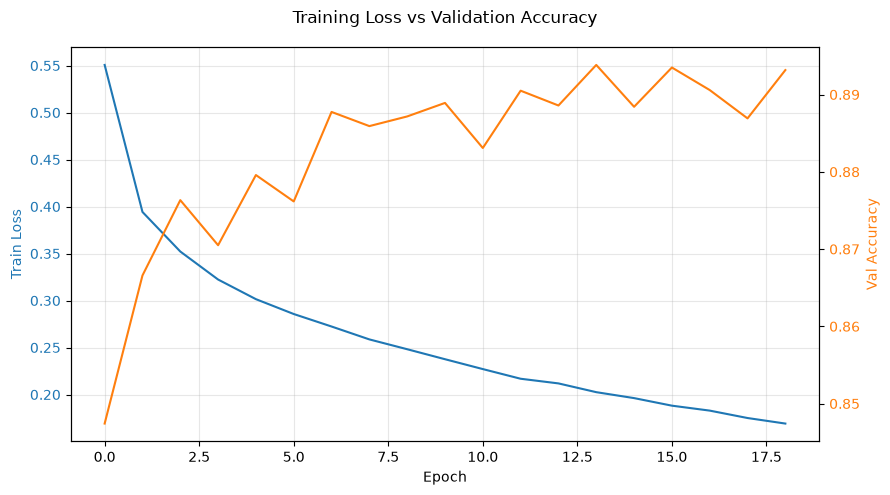

In [25]:
# TODO: plot training loss and validation accuracy curves, report test accuracy

# Combined view: training loss (left axis) and validation accuracy (right axis)
fig, ax1 = plt.subplots(figsize=(9, 5))

color_loss = "tab:blue"
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train Loss", color=color_loss)
ax1.plot(history["train_loss"], color=color_loss, label="Train Loss")
ax1.tick_params(axis="y", labelcolor=color_loss)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color_acc = "tab:orange"
ax2.set_ylabel("Val Accuracy", color=color_acc)
ax2.plot(history["val_acc"], color=color_acc, label="Val Accuracy")
ax2.tick_params(axis="y", labelcolor=color_acc)

fig.suptitle("Training Loss vs Validation Accuracy")
fig.tight_layout()
plt.show()


## Step 4: Confusion matrix

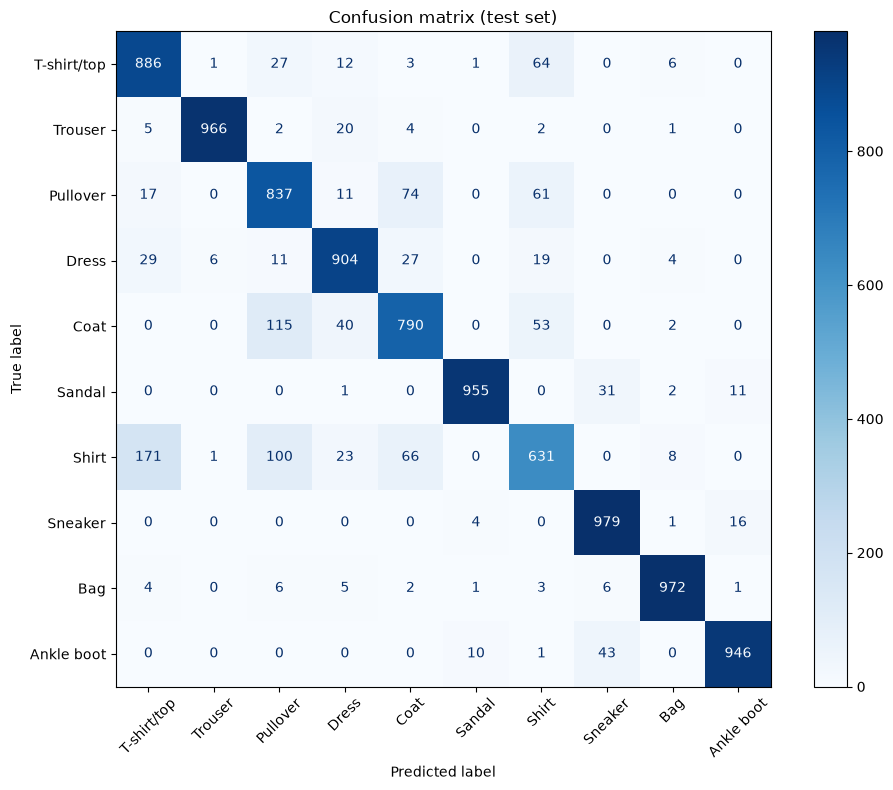

top confusions (true -> predicted):
  Shirt        -> T-shirt/top   (171)
  Coat         -> Pullover      (115)
  Shirt        -> Pullover      (100)
  Pullover     -> Coat          (74)
  Shirt        -> Coat          (66)
  T-shirt/top  -> Shirt         (64)
  Pullover     -> Shirt         (61)
  Coat         -> Shirt         (53)


In [26]:
cm = plot_confusion_matrix(model, test_loader, class_names, device=device)


In [27]:
torch.save(model.state_dict(), "stage_b.pt")

### Written prompt

> **Look at your training curves: validation accuracy flattens while training loss keeps
> falling. Describe what the model is doing in that gap, and explain what your early
> stopping rule actually protected you from.**

Once validation accuracy stops improving, further decreases in training loss mean the
model is fitting idiosyncrasies of the training set (memorising noise, specific pixel
patterns, or rare samples) rather than learning features that generalise. The gap is
the classic signature of overfitting: capacity is still being used, but on the wrong
signal.

Patience-based early stopping protected us from continuing into that regime. By
keeping a cloned snapshot of the weights at the best validation accuracy and restoring
them when the patience counter hits the threshold, we discard the later epochs where
training loss kept falling but generalisation did not improve. Without cloning, the
"best" reference would have been a live view of the final weights and early stopping
would have accomplished nothing.

### Closing reflection

> **Across both days you used a framework to do things you had previously done by hand.
> Name one thing PyTorch genuinely did for you, and one thing it did *not* do (something
> you still had to get right yourself).**

PyTorch handled automatic differentiation and the optimiser update rules: once we
called `loss.backward()` and `optimizer.step()`, the gradients for every parameter in
the MLP were computed and applied without us writing a single partial derivative or
manual weight update. That is genuine labour it took off our hands.

What it did *not* do is enforce a correct problem setup. We still had to make sure
targets were the right shape for MSE, that CrossEntropyLoss received raw logits (no
softmax in the model), that validation was measured in eval mode with no gradients,
that the best state_dict was cloned rather than referenced, and that the early-stopping
patience logic itself was correct. The framework runs whatever graph you give it; the
experimental design and the bugs that silently produce a decreasing-but-meaningless
loss remain the experimenter's responsibility.